# Electrical Time Series Data Classification with FCN

## Prepare Notebook

In [1]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Data Preparation

### Data Loading

In [2]:
import src.data.io as data_io
from src.data.split import stratified_split
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)

# load
ed_data, ed_labels = data_io.load_data_sliding()

X_train, X_test, y_train, y_test = stratified_split(ed_data, ed_labels)
X_train, X_test = clean_train_test(X_train, X_test)
X_train, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_test)

X_train_final, X_val, y_train_final, y_val = stratified_split(X_train, y_train)
y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(
    y_train_final, y_val, y_test
)

print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Stratified split successful
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
Stratified split successful
One-hot encoding complete. Classes: 9

Final shapes:
Train (27105, 30, 5)
Val (6777, 30, 5)
Test (8471, 30, 5)
Classes: 9


### Dataset Size

In [3]:
import numpy as np

train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 31.02 MB


## FCN Model

### Building

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model

def build_fcn(input_shape=(30, 5), num_classes=9):
    inputs = Input(shape=input_shape)

    x = Conv1D(filters=128, kernel_size=8, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=256, kernel_size=5, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling1D()(x)  # FCN’in temel özelliği GAP kullanımı

    outputs = Dense(num_classes, activation='softmax')(x)  # Yalnızca çıkış katmanı Dense olur

    model = Model(inputs, outputs)

    return model

fcn_model = build_fcn()

fcn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

fcn_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30, 5)]           0         
                                                                 
 conv1d (Conv1D)             (None, 30, 128)           5248      
                                                                 
 batch_normalization (Batch  (None, 30, 128)           512       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 30, 128)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 30, 256)           164096    
                                                                 
 batch_normalization_1 (Bat  (None, 30, 256)           1024      
 chNormalization)                                            

In [5]:
from tensorflow.keras.utils import plot_model

plot_model(fcn_model, to_file="fcn_model.png", show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


### Training

In [6]:
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint
)

def train_fcn(model, X_train, y_train, X_val, y_val,
              epochs=30, batch_size=32, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("../../models/standard/best_fcn_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_fcn(fcn_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=32,
                    save_best_model=True)

Epoch 1/50
848/848 [==============================] - 6s 7ms/step - loss: 0.4607 - accuracy: 0.8356 - val_loss: 0.7128 - val_accuracy: 0.7484 - lr: 0.0010
Epoch 2/50
 26/848 [..............................] - ETA: 5s - loss: 0.4087 - accuracy: 0.8365

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


848/848 [==============================] - 6s 7ms/step - loss: 0.3410 - accuracy: 0.8759 - val_loss: 0.3586 - val_accuracy: 0.8787 - lr: 0.0010
Epoch 3/50
848/848 [==============================] - 8s 10ms/step - loss: 0.2926 - accuracy: 0.8931 - val_loss: 0.6818 - val_accuracy: 0.7536 - lr: 0.0010
Epoch 4/50
848/848 [==============================] - 8s 10ms/step - loss: 0.2551 - accuracy: 0.9084 - val_loss: 0.2225 - val_accuracy: 0.9184 - lr: 0.0010
Epoch 5/50
848/848 [==============================] - 6s 7ms/step - loss: 0.2251 - accuracy: 0.9167 - val_loss: 0.1843 - val_accuracy: 0.9332 - lr: 0.0010
Epoch 6/50
848/848 [==============================] - 7s 8ms/step - loss: 0.2062 - accuracy: 0.9248 - val_loss: 0.8608 - val_accuracy: 0.8341 - lr: 0.0010
Epoch 7/50
848/848 [==============================] - 7s 8ms/step - loss: 0.1993 - accuracy: 0.9248 - val_loss: 0.1538 - val_accuracy: 0.9509 - lr: 0.0010
Epoch 8/50
848/848 [==============================] - 6s 8ms/step - loss: 0.172

## Evaluation

### Training Performance

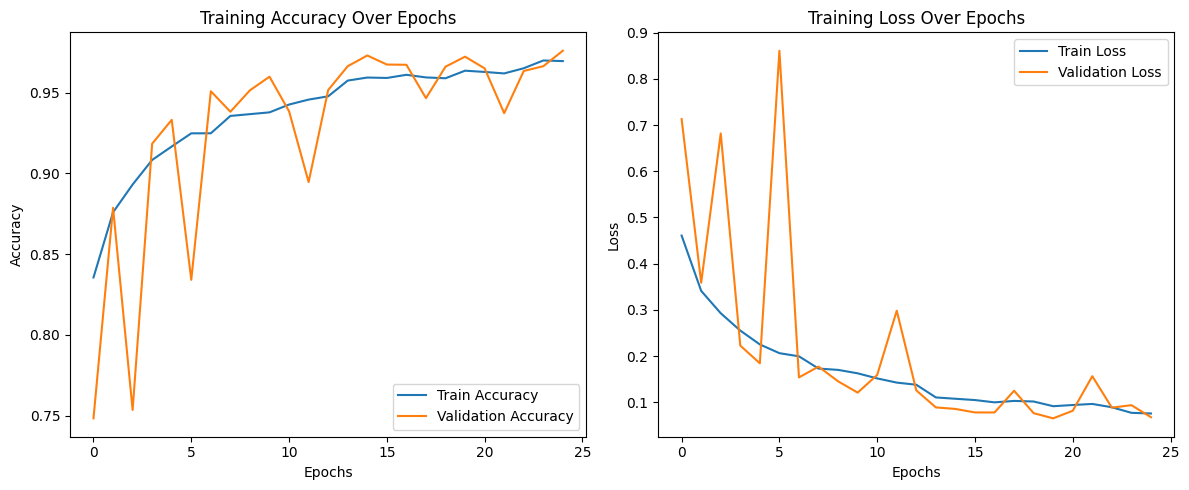

In [7]:
from src.utils.visualization import plot_training_history

plot_training_history(history)

### Classification Metrics

265/265 [==============================] - 1s 2ms/step

Test Accuracy: 0.9773

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    0.9574    0.9783       188
           2     0.9930    0.8386    0.9093       508
           3     0.8676    0.9491    0.9065       373
           4     0.9888    0.9869    0.9879      2603
           5     0.9608    1.0000    0.9800      1938
           6     0.9640    0.9961    0.9798       511
           7     0.9870    0.7755    0.8686        98
           8     0.9843    0.9460    0.9648       463

    accuracy                         0.9773      8471
   macro avg     0.9717    0.9388    0.9528      8471
weighted avg     0.9782    0.9773    0.9770      8471



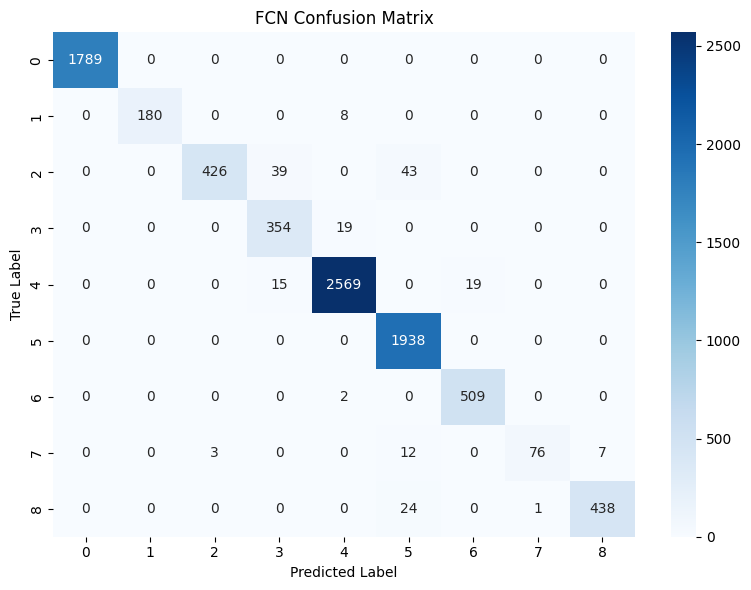

In [8]:
from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)

accuracy, report, y_pred = evaluate_classification(
    fcn_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="FCN Confusion Matrix"
)

### Model Saving and Size Check

In [9]:
import os

fcn_model.save("../../models/fcn_model.h5")

model_size = os.path.getsize("../../models/fcn_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 3.17 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [10]:
from src.deployment.export import export_tflite_int8

TFLITE_MODEL_PATH = "../../models/fcn_model_quantized.tflite"

export_tflite_int8(
    model=fcn_model,
    X_calibration=X_train,
    save_path=TFLITE_MODEL_PATH,
    n_samples=200
)

INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpvmec8rtu/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpvmec8rtu/assets
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-02-25 21:50:29.714019: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-02-25 21:50:29.714029: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Quantized model saved: ../../models/fcn_model_quantized.tflite (283.66 KB)


2026-02-25 21:50:29.714174: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpvmec8rtu
2026-02-25 21:50:29.715257: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-02-25 21:50:29.715261: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpvmec8rtu
2026-02-25 21:50:29.717121: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-02-25 21:50:29.717914: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-02-25 21:50:29.751339: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpvmec8rtu
2026-02-25 21:50:29.760643: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 

b' \x00\x00\x00TFL3\x00\x00\x00\x00\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x80\x00\x00\x00\xd8\x00\x00\x00T#\x04\x00d#\x04\x00\xe4m\x04\x00\x03\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00r\xda\xfb\xff\x0c\x00\x00\x00\x1c\x00\x00\x008\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x9c\xff\xff\xff\x18\x00\x00\x00\x04\x00\x00\x00\x05\x00\x00\x00dense\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00b\xdc\xfb\xff\x04\x00\x00\x00\x07\x00\x00\x00input_1\x00\x02\x00\x00\x004\x00\x00\x00\x04\x00\x00\x00\xdc\xff\xff\xff\x1b\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00CONVERSION_METADATA\x00\x08\x00\x0c\x00\x08\x00\x04\x00\x08\x00\x00\x00\x1a\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00min_runtime_version\x00\x1c\x00\x00\x00x"\x04\x00p"\x04\x00\\"\x04\x00@"\x04\x00$"\x04\x00\x10"\x04\x00\xdc!\x04\x00L\x1d\x04\x00<\x1b\x04\x00,\x9b\x02\x00\x1c\x97\x02\x00\x0c\x17\x00\x00\xfc\x14\x00\x00\xec\x00\x00\x00\x

### Evaluation

In [11]:
from src.deployment.inference import (
    load_tflite_model, 
    run_tflite_inference
)

interpreter = load_tflite_model(TFLITE_MODEL_PATH)

y_pred = run_tflite_inference(interpreter, X_test)
y_true = np.argmax(y_test, axis=1)

print("TFLite model prediction completed.")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite model prediction completed.


### Test Classification Report

In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9780
Precision: 0.9786
Recall: 0.9780
F1-score: 0.9778

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    0.9521    0.9755       188
           2     0.9932    0.8622    0.9231       508
           3     0.8762    0.9491    0.9112       373
           4     0.9885    0.9873    0.9879      2603
           5     0.9651    1.0000    0.9823      1938
           6     0.9677    0.9961    0.9817       511
           7     0.8791    0.8163    0.8466        98
           8     0.9885    0.9244    0.9554       463

    accuracy                         0.9780      8471
   macro avg     0.9620    0.9431    0.9515      8471
weighted avg     0.9786    0.9780    0.9778      8471



### Confusion Matrix

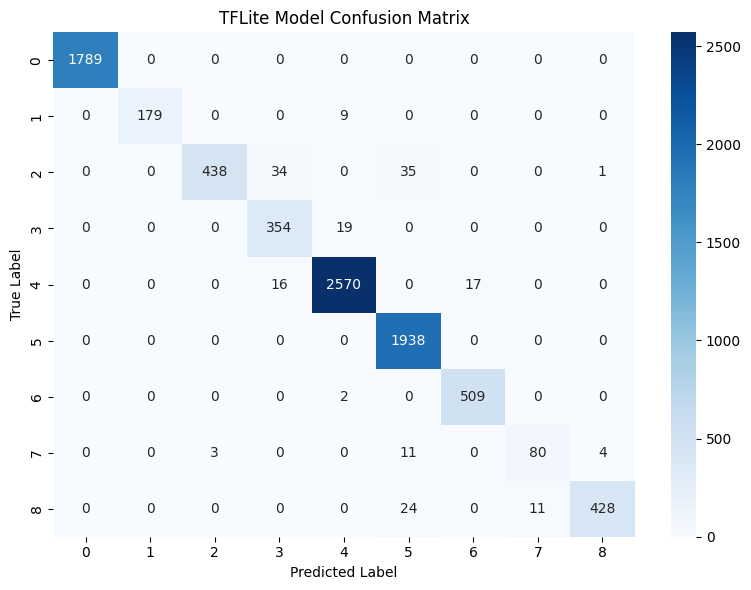

In [13]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

### Model Size

In [15]:
import os

tflite_model_path = "../../models/tinyml/fcn_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 283.66 KB


### ESP32 Compatible Header File Creation

In [18]:
from src.deployment.export import tflite_to_c_header

tflite_to_c_header(
    "../../models/tinyml/fcn_model_quantized.tflite",
    var_name="fcn_model"
)

C header created: ../../models/tinyml/fcn_model_quantized.h
Size: 283.66 KB


PosixPath('../../models/tinyml/fcn_model_quantized.h')